# Notebook 06: Scope Comparison — PINNs vs HJB/PMP

This notebook compares two different nonlinear problem classes:

- **Part A:** a nonlinear optimal control problem, where PMP/HJB ideas are natural.
- **Part B:** a nonlinear boundary-value problem, where a PINN is natural.

The point is not that one framework is universally better. The point is that method choice should match the mathematical structure of the problem.


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_bvp, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from tqdm.auto import trange
import pandas as pd

ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
if not ROOT.exists():
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import set_global_seed, get_device

set_global_seed(42)
device = get_device()
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["figure.dpi"] = 140
NOTEBOOK_NAME = "06_scope_comparison_pinn_vs_hjb_pmp"
OUTDIR = ROOT / "notebooks" / "debug_outputs" / NOTEBOOK_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name: str):
    fig.tight_layout()
    fig.savefig(OUTDIR / name, bbox_inches="tight")

print("device:", device)

c:\Users\Mohammad Belal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


## Part A: Nonlinear optimal control for a pendulum

We solve a finite-horizon nonlinear pendulum regulation problem with a Pontryagin-style two-point boundary-value formulation. This is the right conceptual setting for HJB/PMP: the unknown is an optimal control policy or optimality system, not just a state field.


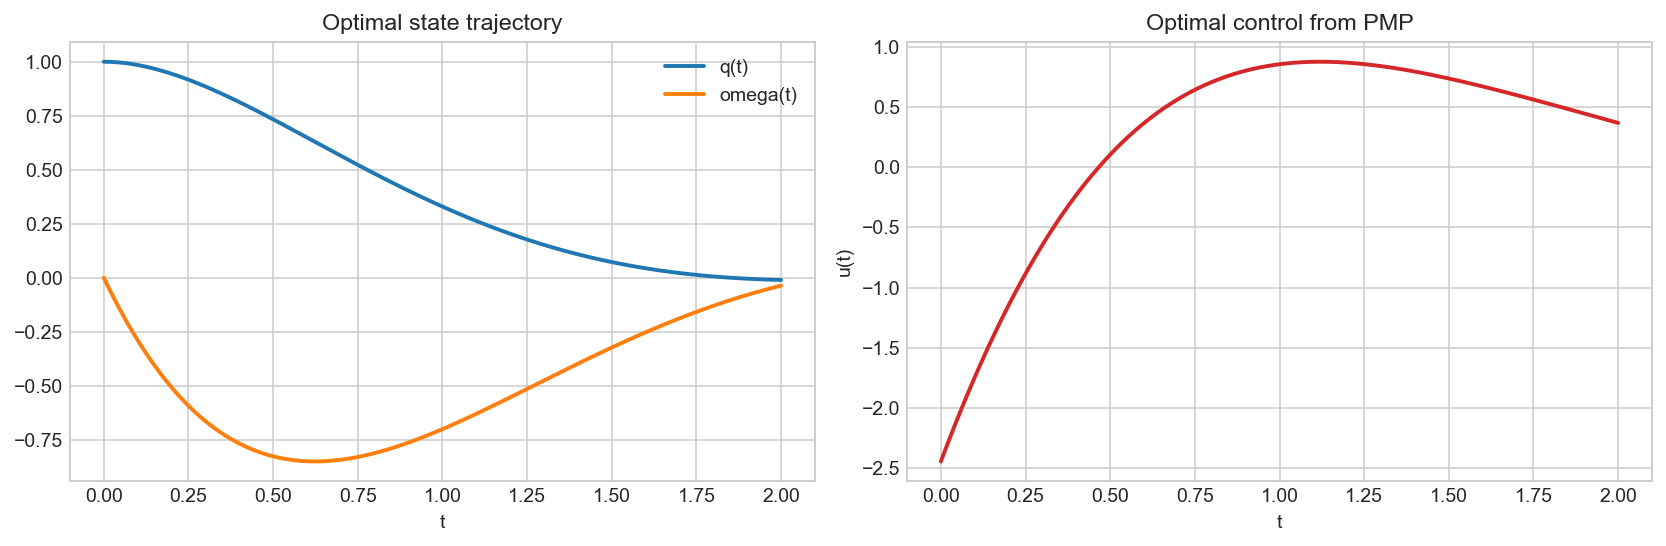

In [2]:
T_FINAL = 2.0
damping = 0.2
r_u = 0.1
q0 = 1.0
w0 = 0.0
qf_weight = 8.0
wf_weight = 1.0

t_mesh = np.linspace(0.0, T_FINAL, 160)

def pmp_ode(t, Y):
    q, w, lam_q, lam_w = Y
    u = -lam_w / (2.0 * r_u)
    dq = w
    dw = -np.sin(q) - damping * w + u
    dlam_q = -2.0 * q + lam_w * np.cos(q)
    dlam_w = -0.2 * w - lam_q + damping * lam_w
    return np.vstack((dq, dw, dlam_q, dlam_w))

def pmp_bc(ya, yb):
    return np.array([
        ya[0] - q0,
        ya[1] - w0,
        yb[2] - 2.0 * qf_weight * yb[0],
        yb[3] - 2.0 * wf_weight * yb[1],
    ])

y_guess = np.zeros((4, t_mesh.size))
y_guess[0] = q0 * np.exp(-t_mesh)
pmp_solution = solve_bvp(pmp_ode, pmp_bc, t_mesh, y_guess, tol=1e-4, max_nodes=10000)
assert pmp_solution.success, pmp_solution.message

t_plot = np.linspace(0.0, T_FINAL, 400)
q_opt, w_opt, lam_q_opt, lam_w_opt = pmp_solution.sol(t_plot)
u_opt = -lam_w_opt / (2.0 * r_u)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_plot, q_opt, label="q(t)", linewidth=2)
axes[0].plot(t_plot, w_opt, label="omega(t)", linewidth=2)
axes[0].set_title("Optimal state trajectory")
axes[0].set_xlabel("t")
axes[0].legend()

axes[1].plot(t_plot, u_opt, color="tab:red", linewidth=2)
axes[1].set_title("Optimal control from PMP")
axes[1].set_xlabel("t")
axes[1].set_ylabel("u(t)")

savefig(fig, "scope_control_example.png")
plt.show()

## Part B: Nonlinear BVP solved with a PINN

We now revisit a smaller Bratu problem. Here the unknown is a state function that must satisfy a nonlinear differential equation and two boundary conditions. A PINN is a direct fit for that structure.


Training compact Bratu PINN: 100%|██████████| 2500/2500 [00:03<00:00, 718.50it/s]


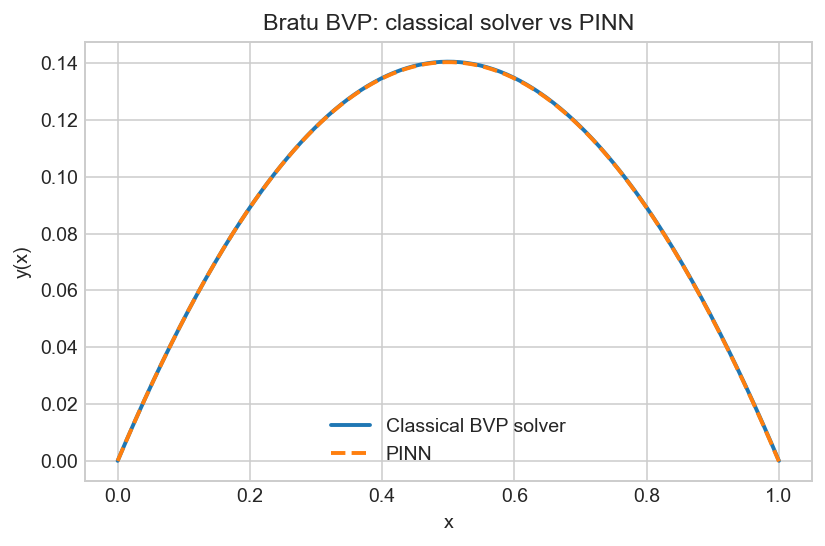

In [3]:
LAM = 1.0
x_ref = np.linspace(0.0, 1.0, 300)

def bratu_fun(x, y):
    return np.vstack((y[1], -LAM * np.exp(y[0])))

def bratu_bc(ya, yb):
    return np.array([ya[0], yb[0]])

ref_solution = solve_bvp(bratu_fun, bratu_bc, np.linspace(0.0, 1.0, 40), np.zeros((2, 40)), tol=1e-8, max_nodes=5000)
assert ref_solution.success, ref_solution.message
y_ref = ref_solution.sol(x_ref)[0]

class SmallBratuPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 48), nn.Tanh(),
            nn.Linear(48, 48), nn.Tanh(),
            nn.Linear(48, 48), nn.Tanh(),
            nn.Linear(48, 1),
        )

    def forward(self, x):
        return self.net(x)

def bratu_terms(model, x):
    y = model(x)
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return y, ddy + LAM * torch.exp(y)

model = SmallBratuPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in trange(2500, desc="Training compact Bratu PINN"):
    optimizer.zero_grad()
    x_f = torch.rand(128, 1, device=device, requires_grad=True)
    _, residual = bratu_terms(model, x_f)
    loss_pde = (residual ** 2).mean()
    x_b = torch.tensor([[0.0], [1.0]], dtype=torch.float32, device=device)
    loss_bc = (model(x_b) ** 2).mean()
    loss = loss_pde + 10.0 * loss_bc
    loss.backward()
    optimizer.step()

x_plot_t = torch.tensor(x_ref.reshape(-1, 1), dtype=torch.float32, device=device)
y_pred = model(x_plot_t).detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_ref, y_ref, label="Classical BVP solver", linewidth=2)
ax.plot(x_ref, y_pred, "--", label="PINN", linewidth=2)
ax.set_title("Bratu BVP: classical solver vs PINN")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.legend()
savefig(fig, "scope_bratu_example.png")
plt.show()

## Summary table

The comparison is about *problem class* and *natural applicability*, not about declaring one method globally superior.


In [4]:
summary_df = pd.DataFrame([
    {
        "problem_type": "Nonlinear optimal control",
        "state/control_dimension": "2 state, 1 control",
        "outputs_sought": "Optimal trajectory and torque",
        "natural_method": "HJB / PMP",
        "main_limitation": "Curse of dimensionality or BVP sensitivity",
    },
    {
        "problem_type": "Nonlinear BVP / PDE solve",
        "state/control_dimension": "Field over space-time",
        "outputs_sought": "State function satisfying PDE/BC/IC",
        "natural_method": "PINN",
        "main_limitation": "Training can be slow or optimization-sensitive",
    },
    {
        "problem_type": "Inverse parameter identification",
        "state/control_dimension": "Field + latent parameters",
        "outputs_sought": "State and hidden coefficients",
        "natural_method": "PINN",
        "main_limitation": "Identifiability and data quality matter",
    },
])
display(summary_df)

,problem_type,state/control_dimension,outputs_sought,natural_method,main_limitation
0,Nonlinear optimal control,"2 state, 1 control",Optimal trajectory and torque,HJB / PMP,Curse of dimensionality or BVP sensitivity
1,Nonlinear BVP / PDE solve,Field over space-time,State function satisfying PDE/BC/IC,PINN,Training can be slow or optimization-sensitive
2,Inverse parameter identification,Field + latent parameters,State and hidden coefficients,PINN,Identifiability and data quality matter


## Key takeaway

- PINNs are powerful for nonlinear differential equations, boundary-value problems, and inverse problems.
- HJB and PMP are specialized tools for optimal control.
- Standard PINNs can struggle on shocks, stiff systems, and multiscale or high-frequency solutions.
- Method choice should depend on the mathematical structure of the problem.
